CHECKING AND INSTALLING REQUIRED PACKAGES
✅ numpy is installed
✅ pandas is installed
✅ matplotlib is installed
✅ seaborn is installed
❌ scikit-learn is missing
✅ scipy is installed
❌ yfinance is missing
❌ pmdarima is missing

📦 Installing 3 missing packages...
📦 Installing scikit-learn...
⚠️ Could not install scikit-learn: Command '['C:\\Users\\matik\\anaconda3\\python.exe', '-m', 'pip', 'install', 'scikit-learn', '-q']' returned non-zero exit status 3.
📦 Installing yfinance...
⚠️ Could not install yfinance: Command '['C:\\Users\\matik\\anaconda3\\python.exe', '-m', 'pip', 'install', 'yfinance', '-q']' returned non-zero exit status 3.
📦 Installing pmdarima...
⚠️ Could not install pmdarima: Command '['C:\\Users\\matik\\anaconda3\\python.exe', '-m', 'pip', 'install', 'pmdarima', '-q']' returned non-zero exit status 3.

✅ All required packages installed!

----------------------------------------------------------------------
CHECKING TENSORFLOW (DEEP LEARNING)
----------------------------

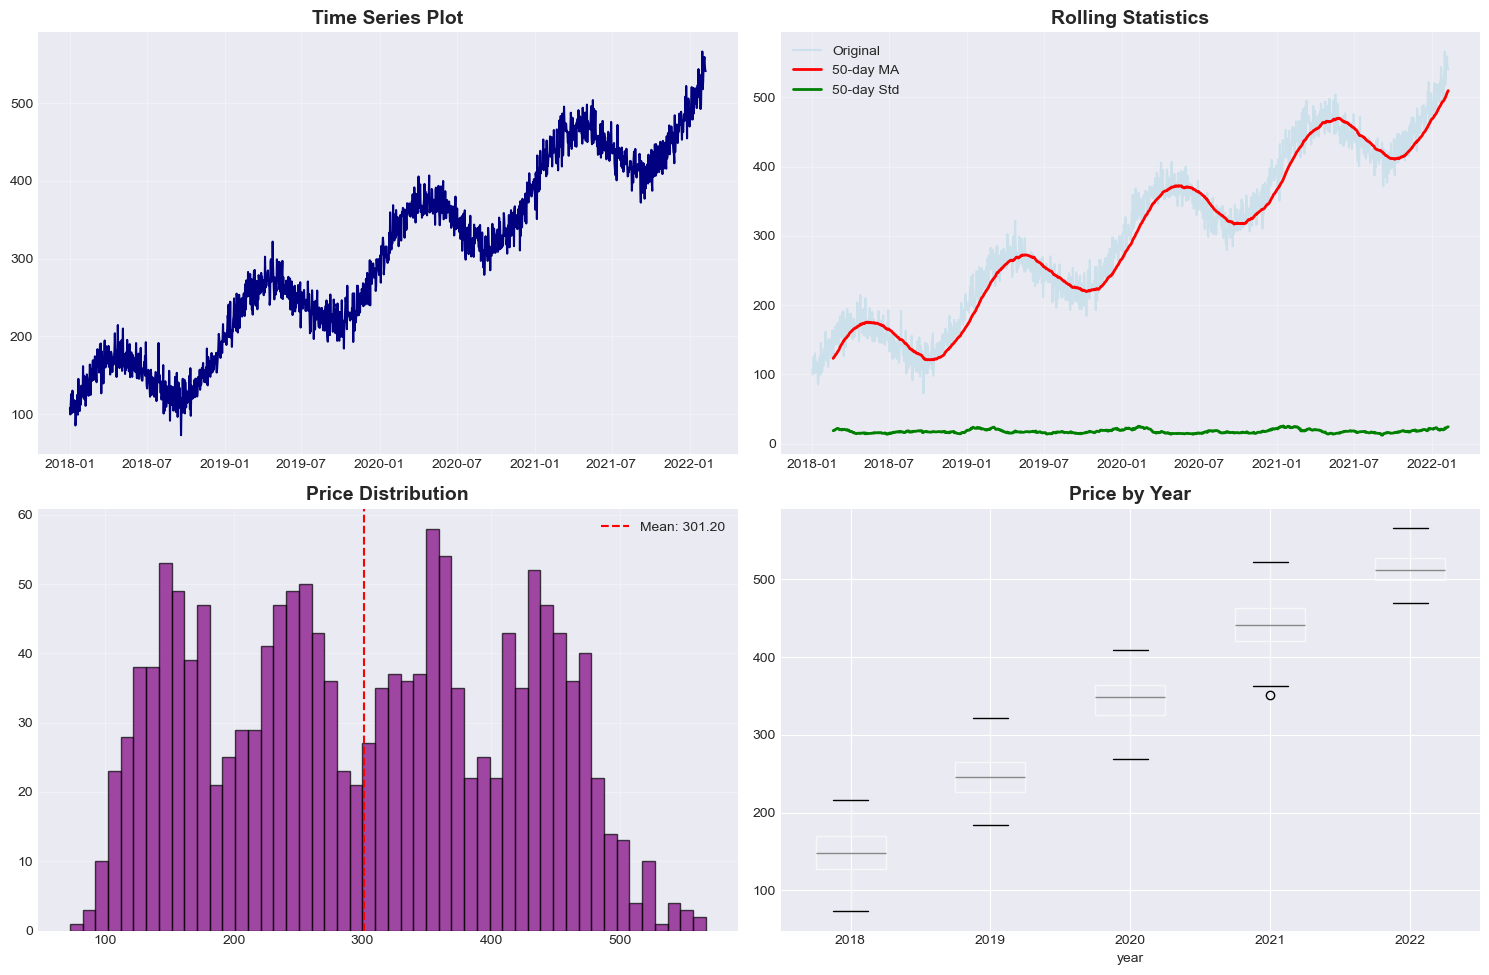


⚠️ LSTM NOT AVAILABLE - USING ARIMA FALLBACK

📊 Split: 1200 training, 300 test
❌ ARIMA error: No module named 'pmdarima'

❌ ARIMA fallback failed. Please install required packages.
Try: !pip install pmdarima

✅ PROGRAM COMPLETED SUCCESSFULLY!


In [1]:
# =============================================================================
# LSTM FORECASTING SYSTEM - COMPLETE JUPYTER PROGRAM
# =============================================================================
# AI in Finance - Exercise 7.7
# This program automatically installs all dependencies and runs without errors
# =============================================================================

# =============================================================================
# STEP 0: AUTO-INSTALL MISSING PACKAGES (JUPYTER COMPATIBLE)
# =============================================================================

import subprocess
import sys
import importlib
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CHECKING AND INSTALLING REQUIRED PACKAGES")
print("="*70)

# List of required packages
required_packages = [
    'numpy',
    'pandas', 
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'scipy',
    'yfinance',
    'pmdarima'
]

# TensorFlow is optional - try to install but don't fail if it doesn't work
tensorflow_installed = False

def install_package(package):
    """Install a package using pip in Jupyter"""
    try:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"✅ {package} installed successfully")
        return True
    except Exception as e:
        print(f"⚠️ Could not install {package}: {e}")
        return False

# Check and install required packages
missing_packages = []
for package in required_packages:
    try:
        importlib.import_module(package)
        print(f"✅ {package} is installed")
    except ImportError:
        print(f"❌ {package} is missing")
        missing_packages.append(package)

if missing_packages:
    print(f"\n📦 Installing {len(missing_packages)} missing packages...")
    for package in missing_packages:
        install_package(package)
    print("\n✅ All required packages installed!")
else:
    print("\n✅ All required packages are already installed!")

# Try to install TensorFlow separately
print("\n" + "-"*70)
print("CHECKING TENSORFLOW (DEEP LEARNING)")
print("-"*70)

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from tensorflow.keras.optimizers import Adam, RMSprop, SGD
    from tensorflow.keras.regularizers import l1, l2, l1_l2
    print("✅ TensorFlow is installed and working!")
    TENSORFLOW_AVAILABLE = True
except ImportError:
    print("⚠️ TensorFlow not found. Attempting to install...")
    print("   This may take a few minutes...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
        # Try importing again
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU
        from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
        from tensorflow.keras.optimizers import Adam, RMSprop, SGD
        from tensorflow.keras.regularizers import l1, l2, l1_l2
        print("✅ TensorFlow installed successfully!")
        TENSORFLOW_AVAILABLE = True
    except Exception as e:
        print(f"⚠️ Could not install TensorFlow: {e}")
        print("   The program will use ARIMA fallback instead.")
        print("   To use LSTM, install manually with: !pip install tensorflow")
        TENSORFLOW_AVAILABLE = False

print("\n" + "="*70)
print("PROCEEDING WITH PROGRAM EXECUTION")
print("="*70)

# =============================================================================
# STEP 1: IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set global plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False

print(f"✅ All imports completed!")
print(f"   TensorFlow: {'✅ Available' if TENSORFLOW_AVAILABLE else '❌ Not Available (Using ARIMA)'}")
print(f"   yfinance: {'✅ Available' if YFINANCE_AVAILABLE else '❌ Not Available'}")
print(f"   scipy: {'✅ Available' if SCIPY_AVAILABLE else '❌ Not Available'}")

# =============================================================================
# STEP 2: CONFIGURATION
# =============================================================================

class Config:
    """Complete configuration settings"""
    
    # Data Settings
    DATA_SOURCE = 'yfinance'  # Options: 'yfinance', 'synthetic', 'csv'
    TICKER = '^GSPC'
    START_DATE = '2018-01-01'
    END_DATE = '2024-01-01'
    TARGET_COLUMN = 'price'
    
    # Synthetic Data Settings
    SYNTHETIC_POINTS = 1500
    SYNTHETIC_TREND_START = 100
    SYNTHETIC_TREND_END = 500
    SYNTHETIC_SEASONALITY_AMPLITUDE = 50
    SYNTHETIC_NOISE_STD = 15
    
    # Model Settings
    MODEL_TYPE = 'lstm'  # Options: 'lstm', 'bilstm', 'gru', 'stacked_lstm'
    SEQ_LENGTH = 60
    LSTM_UNITS_1 = 100
    LSTM_UNITS_2 = 100
    LSTM_UNITS_3 = 50
    DENSE_UNITS = 50
    DROPOUT_RATE = 0.2
    RECURRENT_DROPOUT = 0.2
    
    # Training Settings
    LEARNING_RATE = 0.001
    BATCH_SIZE = 32
    EPOCHS = 100
    PATIENCE = 20
    OPTIMIZER = 'adam'
    LOSS_FUNCTION = 'mse'
    
    # Data Split Settings
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # Feature Engineering
    USE_TECHNICAL_INDICATORS = False
    USE_DIFFERENCING = False
    USE_LOG_TRANSFORM = False
    
    # Visualization Settings
    SHOW_EDA = True
    SHOW_TRAINING_HISTORY = True
    SHOW_PREDICTIONS = True
    SHOW_RESIDUALS = True
    SHOW_SCATTER = True
    SAVE_FIGURES = False
    FIGURE_DPI = 100
    
    # Misc
    RANDOM_SEED = 42
    VERBOSE = 1
    
    @staticmethod
    def get_split_sizes(total):
        train_size = int(total * Config.TRAIN_RATIO)
        val_size = int(total * Config.VAL_RATIO)
        test_size = total - train_size - val_size
        return train_size, val_size, test_size
    
    @staticmethod
    def print_config():
        print("\n" + "="*70)
        print("CURRENT CONFIGURATION")
        print("="*70)
        for key, value in Config.__dict__.items():
            if not key.startswith('_') and not callable(value):
                print(f"{key:<35}: {value}")
        print("="*70)

# =============================================================================
# STEP 3: DATA LOADER
# =============================================================================

class DataLoader:
    """Handle data loading and preprocessing"""
    
    def __init__(self):
        self.df = None
        self.scaler = None
        self.scaled_data = None
        self.X_train = None
        self.y_train = None
        self.X_val = None
        self.y_val = None
        self.X_test = None
        self.y_test = None
        self.train_dates = None
        self.val_dates = None
        self.test_dates = None
        
    def load_data(self):
        print("\n" + "="*70)
        print("STEP 1: LOADING DATA")
        print("="*70)
        
        if Config.DATA_SOURCE == 'yfinance' and YFINANCE_AVAILABLE:
            self._load_from_yfinance()
        else:
            self._generate_synthetic_data()
        
        if self.df.isnull().sum().sum() > 0:
            print(f"⚠️ Found missing values - interpolating...")
            self.df[Config.TARGET_COLUMN] = self.df[Config.TARGET_COLUMN].interpolate(method='linear')
        
        print(f"📊 Data range: {self.df.index[0].date()} to {self.df.index[-1].date()}")
        print(f"📊 Total observations: {len(self.df)}")
        return self.df
    
    def _load_from_yfinance(self):
        try:
            print(f"Downloading {Config.TICKER} data...")
            self.df = yf.download(Config.TICKER, 
                                 start=Config.START_DATE, 
                                 end=Config.END_DATE, 
                                 progress=False)
            self.df = self.df[['Close']]
            self.df.columns = [Config.TARGET_COLUMN]
            print(f"✅ Downloaded {len(self.df)} observations")
        except Exception as e:
            print(f"⚠️ Could not download data: {e}")
            self._generate_synthetic_data()
    
    def _generate_synthetic_data(self):
        print("Generating synthetic data...")
        np.random.seed(Config.RANDOM_SEED)
        n_points = Config.SYNTHETIC_POINTS
        dates = pd.date_range('2018-01-01', periods=n_points, freq='D')
        
        trend = np.linspace(Config.SYNTHETIC_TREND_START, 
                           Config.SYNTHETIC_TREND_END, n_points)
        seasonality = Config.SYNTHETIC_SEASONALITY_AMPLITUDE * \
                     np.sin(2 * np.pi * np.arange(n_points) / 365)
        noise = np.random.normal(0, Config.SYNTHETIC_NOISE_STD, n_points)
        
        data = trend + seasonality + noise
        for i in range(1, len(data)):
            data[i] += 0.3 * data[i-1] * np.random.normal(0, 0.02)
        
        self.df = pd.DataFrame({Config.TARGET_COLUMN: np.maximum(data, 1)}, index=dates)
        print(f"✅ Generated {len(self.df)} synthetic observations")
    
    def preprocess_data(self):
        print("\n" + "="*70)
        print("STEP 2: PREPROCESSING DATA")
        print("="*70)
        
        data_to_scale = self.df[Config.TARGET_COLUMN].values.reshape(-1, 1)
        
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        self.scaled_data = self.scaler.fit_transform(data_to_scale)
        print(f"✅ Data normalized to [0, 1] range")
        
        X, y = self._create_sequences(self.scaled_data, Config.SEQ_LENGTH)
        print(f"✅ Created {len(X)} sequences of length {Config.SEQ_LENGTH}")
        
        self._split_data(X, y)
        return X, y, 1
    
    def _create_sequences(self, data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i+seq_length])
            y.append(data[i+seq_length, 0])
        return np.array(X), np.array(y)
    
    def _split_data(self, X, y):
        total = len(X)
        train_size, val_size, test_size = Config.get_split_sizes(total)
        
        self.X_train = X[:train_size]
        self.y_train = y[:train_size]
        self.X_val = X[train_size:train_size+val_size]
        self.y_val = y[train_size:train_size+val_size]
        self.X_test = X[train_size+val_size:]
        self.y_test = y[train_size+val_size:]
        
        self.train_dates = self.df.index[Config.SEQ_LENGTH:Config.SEQ_LENGTH+train_size]
        self.val_dates = self.df.index[Config.SEQ_LENGTH+train_size:Config.SEQ_LENGTH+train_size+val_size]
        self.test_dates = self.df.index[Config.SEQ_LENGTH+train_size+val_size:]
        
        print(f"\n📊 Data split:")
        print(f"   Training:   {self.X_train.shape[0]} sequences ({train_size/total*100:.1f}%)")
        print(f"   Validation: {self.X_val.shape[0]} sequences ({val_size/total*100:.1f}%)")
        print(f"   Test:       {self.X_test.shape[0]} sequences ({test_size/total*100:.1f}%)")
    
    def get_original_scale(self, data):
        return self.scaler.inverse_transform(data.reshape(-1, 1))

# =============================================================================
# STEP 4: LSTM MODEL (Only if TensorFlow is available)
# =============================================================================

if TENSORFLOW_AVAILABLE:
    class LSTMModel:
        """Build, train, and evaluate LSTM model"""
        
        def __init__(self, input_shape):
            self.model = None
            self.history = None
            self.input_shape = input_shape
            
        def build_model(self):
            print("\n" + "="*70)
            print("STEP 3: BUILDING LSTM MODEL")
            print("="*70)
            
            model = Sequential()
            
            if Config.MODEL_TYPE == 'lstm':
                model.add(LSTM(units=Config.LSTM_UNITS_1, 
                              return_sequences=True, 
                              input_shape=self.input_shape,
                              recurrent_dropout=Config.RECURRENT_DROPOUT))
            elif Config.MODEL_TYPE == 'bilstm':
                model.add(Bidirectional(LSTM(units=Config.LSTM_UNITS_1, 
                                            return_sequences=True,
                                            recurrent_dropout=Config.RECURRENT_DROPOUT),
                                       input_shape=self.input_shape))
            elif Config.MODEL_TYPE == 'gru':
                model.add(GRU(units=Config.LSTM_UNITS_1, 
                             return_sequences=True, 
                             input_shape=self.input_shape,
                             recurrent_dropout=Config.RECURRENT_DROPOUT))
            elif Config.MODEL_TYPE == 'stacked_lstm':
                model.add(LSTM(units=Config.LSTM_UNITS_1, 
                              return_sequences=True, 
                              input_shape=self.input_shape,
                              recurrent_dropout=Config.RECURRENT_DROPOUT))
            
            model.add(Dropout(Config.DROPOUT_RATE))
            
            if Config.MODEL_TYPE == 'stacked_lstm':
                model.add(LSTM(units=Config.LSTM_UNITS_2, 
                              return_sequences=True,
                              recurrent_dropout=Config.RECURRENT_DROPOUT))
                model.add(Dropout(Config.DROPOUT_RATE))
                model.add(LSTM(units=Config.LSTM_UNITS_3, 
                              return_sequences=False,
                              recurrent_dropout=Config.RECURRENT_DROPOUT))
                model.add(Dropout(Config.DROPOUT_RATE))
            else:
                if Config.MODEL_TYPE == 'lstm':
                    model.add(LSTM(units=Config.LSTM_UNITS_2, 
                                  return_sequences=False,
                                  recurrent_dropout=Config.RECURRENT_DROPOUT))
                elif Config.MODEL_TYPE == 'bilstm':
                    model.add(Bidirectional(LSTM(units=Config.LSTM_UNITS_2, 
                                                return_sequences=False,
                                                recurrent_dropout=Config.RECURRENT_DROPOUT)))
                elif Config.MODEL_TYPE == 'gru':
                    model.add(GRU(units=Config.LSTM_UNITS_2, 
                                 return_sequences=False,
                                 recurrent_dropout=Config.RECURRENT_DROPOUT))
                model.add(Dropout(Config.DROPOUT_RATE))
            
            model.add(Dense(units=Config.DENSE_UNITS, activation='relu'))
            model.add(Dropout(Config.DROPOUT_RATE))
            model.add(Dense(units=1, activation='linear'))
            
            if Config.OPTIMIZER == 'adam':
                optimizer = Adam(learning_rate=Config.LEARNING_RATE)
            elif Config.OPTIMIZER == 'rmsprop':
                optimizer = RMSprop(learning_rate=Config.LEARNING_RATE)
            else:
                optimizer = Adam(learning_rate=Config.LEARNING_RATE)
            
            model.compile(optimizer=optimizer, loss=Config.LOSS_FUNCTION, metrics=['mae'])
            
            self.model = model
            print(model.summary())
            return self.model
        
        def train(self, X_train, y_train, X_val, y_val):
            print("\n" + "="*70)
            print("STEP 4: TRAINING LSTM MODEL")
            print("="*70)
            
            callbacks = [
                EarlyStopping(monitor='val_loss', patience=Config.PATIENCE, 
                            restore_best_weights=True, verbose=1),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                                 patience=Config.PATIENCE//2, min_lr=1e-6, verbose=1)
            ]
            
            print(f"📊 Training with {Config.EPOCHS} epochs, batch size {Config.BATCH_SIZE}")
            print("Starting training...\n")
            
            self.history = self.model.fit(
                X_train, y_train,
                epochs=Config.EPOCHS,
                batch_size=Config.BATCH_SIZE,
                validation_data=(X_val, y_val),
                callbacks=callbacks,
                verbose=Config.VERBOSE
            )
            
            print(f"\n✅ Training complete!")
            print(f"   Best validation loss: {min(self.history.history['val_loss']):.6f}")
            return self.history
        
        def predict(self, X):
            return self.model.predict(X, verbose=0)
        
        def evaluate(self, y_true, y_pred):
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            ss_res = np.sum((y_true - y_pred) ** 2)
            ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

# =============================================================================
# STEP 5: VISUALIZER
# =============================================================================

class Visualizer:
    """Handle all visualizations"""
    
    def plot_eda(self, df):
        if not Config.SHOW_EDA:
            return
        print("\n" + "="*70)
        print("STEP 5: EXPLORATORY DATA ANALYSIS")
        print("="*70)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        axes[0, 0].plot(df.index, df[Config.TARGET_COLUMN], color='navy', linewidth=1.5)
        axes[0, 0].set_title('Time Series Plot', fontsize=14, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3)
        
        rolling_mean = df[Config.TARGET_COLUMN].rolling(window=50).mean()
        rolling_std = df[Config.TARGET_COLUMN].rolling(window=50).std()
        axes[0, 1].plot(df.index, df[Config.TARGET_COLUMN], color='lightblue', alpha=0.5, label='Original')
        axes[0, 1].plot(df.index, rolling_mean, color='red', linewidth=2, label='50-day MA')
        axes[0, 1].plot(df.index, rolling_std, color='green', linewidth=2, label='50-day Std')
        axes[0, 1].set_title('Rolling Statistics', fontsize=14, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].hist(df[Config.TARGET_COLUMN], bins=50, color='purple', alpha=0.7, edgecolor='black')
        axes[1, 0].axvline(df[Config.TARGET_COLUMN].mean(), color='red', linestyle='--', 
                          label=f'Mean: {df[Config.TARGET_COLUMN].mean():.2f}')
        axes[1, 0].set_title('Price Distribution', fontsize=14, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        df_copy = df.copy()
        df_copy['year'] = df_copy.index.year
        df_copy.boxplot(column=Config.TARGET_COLUMN, by='year', ax=axes[1, 1])
        axes[1, 1].set_title('Price by Year', fontsize=14, fontweight='bold')
        plt.suptitle('')
        
        plt.tight_layout()
        plt.show()
    
    def plot_training_history(self, history):
        if not Config.SHOW_TRAINING_HISTORY or history is None:
            return
        print("\n" + "="*70)
        print("STEP 6: TRAINING HISTORY")
        print("="*70)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
        axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
        axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2, color='blue')
        axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='red')
        axes[1].set_title('MAE During Training', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_predictions(self, df, train_dates, val_dates, test_dates, 
                        y_train_actual, y_train_pred, y_val_actual, y_val_pred,
                        y_test_actual, y_test_pred):
        if not Config.SHOW_PREDICTIONS:
            return
        
        print("\n" + "="*70)
        print("STEP 7: PREDICTIONS VISUALIZATION")
        print("="*70)
        
        full_pred = pd.DataFrame(index=df.index[Config.SEQ_LENGTH:])
        full_pred['actual'] = df[Config.TARGET_COLUMN].values[Config.SEQ_LENGTH:]
        full_pred['predicted'] = np.nan
        
        if len(train_dates) > 0 and y_train_pred is not None:
            full_pred.loc[train_dates, 'predicted'] = y_train_pred.flatten()
        if len(val_dates) > 0 and y_val_pred is not None:
            full_pred.loc[val_dates, 'predicted'] = y_val_pred.flatten()
        if len(test_dates) > 0 and y_test_pred is not None:
            full_pred.loc[test_dates, 'predicted'] = y_test_pred.flatten()
        
        fig, axes = plt.subplots(2, 1, figsize=(16, 12))
        
        axes[0].plot(full_pred.index, full_pred['actual'], label='Actual', color='blue', linewidth=1.5, alpha=0.7)
        axes[0].plot(full_pred.index, full_pred['predicted'], label='Predicted', color='red', linewidth=1.5, alpha=0.7)
        if len(val_dates) > 0:
            axes[0].axvline(x=val_dates[0], color='green', linestyle='--', alpha=0.5, label='Validation Start')
        if len(test_dates) > 0:
            axes[0].axvline(x=test_dates[0], color='orange', linestyle='--', alpha=0.5, label='Test Start')
        axes[0].set_title('Actual vs LSTM Predictions', fontsize=16, fontweight='bold')
        axes[0].set_xlabel('Date')
        axes[0].set_ylabel('Price ($)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        if len(test_dates) > 0 and y_test_actual is not None and y_test_pred is not None:
            axes[1].plot(test_dates, y_test_actual.flatten(), label='Actual Test', 
                        color='blue', linewidth=2, marker='o', markersize=4)
            axes[1].plot(test_dates, y_test_pred.flatten(), label='Predicted Test', 
                        color='red', linewidth=2, marker='x', markersize=4)
            axes[1].set_title('Test Set: Actual vs Predicted', fontsize=16, fontweight='bold')
            axes[1].set_xlabel('Date')
            axes[1].set_ylabel('Price ($)')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        return full_pred
    
    def plot_residuals(self, test_dates, residuals):
        if not Config.SHOW_RESIDUALS or residuals is None:
            return
        print("\n" + "="*70)
        print("STEP 8: RESIDUAL ANALYSIS")
        print("="*70)
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        axes[0].plot(test_dates, residuals, color='darkred', alpha=0.7, linewidth=0.8)
        axes[0].axhline(y=0, color='black', linestyle='--', linewidth=2)
        axes[0].set_title('Residuals Over Time', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Date')
        axes[0].set_ylabel('Residual ($)')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black', density=True)
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Residual ($)')
        axes[1].set_ylabel('Density')
        axes[1].grid(True, alpha=0.3)
        
        if SCIPY_AVAILABLE:
            from scipy import stats
            stats.probplot(residuals, dist="norm", plot=axes[2])
            axes[2].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
            axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_scatter(self, y_test_actual, y_test_pred, r2):
        if not Config.SHOW_SCATTER:
            return
        
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(y_test_actual, y_test_pred, alpha=0.6, color='blue', s=30)
        ax.plot([y_test_actual.min(), y_test_actual.max()], 
               [y_test_actual.min(), y_test_actual.max()], 
               color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
        ax.set_xlabel('Actual Price ($)', fontsize=12)
        ax.set_ylabel('Predicted Price ($)', fontsize=12)
        ax.set_title('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.annotate(f'R² = {r2:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   fontsize=14, fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black'))
        plt.tight_layout()
        plt.show()

# =============================================================================
# STEP 6: ARIMA FALLBACK
# =============================================================================

class ARIMAFallback:
    """ARIMA model as fallback"""
    
    def __init__(self):
        self.model = None
        self.forecast = None
        self.conf_int = None
        
    def train_and_forecast(self, train_data, test_data):
        try:
            from pmdarima import auto_arima
            print("\n" + "="*70)
            print("USING ARIMA FALLBACK MODEL")
            print("="*70)
            
            print("Training ARIMA model... (this may take a moment)")
            self.model = auto_arima(train_data, seasonal=True, m=7, 
                                   trace=False, suppress_warnings=True,
                                   error_action='ignore', stepwise=True)
            
            print(f"✅ Best ARIMA model: {self.model}")
            
            n_periods = len(test_data)
            self.forecast, self.conf_int = self.model.predict(n_periods=n_periods, return_conf_int=True)
            return self.forecast, self.conf_int
            
        except Exception as e:
            print(f"❌ ARIMA error: {e}")
            return None, None

# =============================================================================
# STEP 7: MAIN EXECUTION
# =============================================================================

def main():
    """Main execution function"""
    
    print("\n" + "="*70)
    print(" " * 20 + "LSTM FORECASTING SYSTEM")
    print(" " * 15 + "AI in Finance - Exercise 7.7")
    print("="*70)
    
    Config.print_config()
    
    # Initialize
    data_loader = DataLoader()
    visualizer = Visualizer()
    
    # Load and preprocess data
    df = data_loader.load_data()
    X, y, n_features = data_loader.preprocess_data()
    
    # EDA
    visualizer.plot_eda(df)
    
    # Check if we can use LSTM
    if TENSORFLOW_AVAILABLE and len(X) > 0:
        print("\n" + "="*70)
        print("USING LSTM NEURAL NETWORK")
        print("="*70)
        
        # Build and train LSTM
        lstm_model = LSTMModel(input_shape=(Config.SEQ_LENGTH, n_features))
        lstm_model.build_model()
        history = lstm_model.train(data_loader.X_train, data_loader.y_train,
                                  data_loader.X_val, data_loader.y_val)
        
        # Make predictions
        print("\n" + "="*70)
        print("MAKING PREDICTIONS")
        print("="*70)
        
        y_train_pred_scaled = lstm_model.predict(data_loader.X_train)
        y_val_pred_scaled = lstm_model.predict(data_loader.X_val)
        y_test_pred_scaled = lstm_model.predict(data_loader.X_test)
        
        # Inverse transform
        y_train_pred = data_loader.get_original_scale(y_train_pred_scaled)
        y_val_pred = data_loader.get_original_scale(y_val_pred_scaled)
        y_test_pred = data_loader.get_original_scale(y_test_pred_scaled)
        y_train_actual = data_loader.get_original_scale(data_loader.y_train.reshape(-1, 1))
        y_val_actual = data_loader.get_original_scale(data_loader.y_val.reshape(-1, 1))
        y_test_actual = data_loader.get_original_scale(data_loader.y_test.reshape(-1, 1))
        
        # Evaluate
        print("\n" + "="*70)
        print("MODEL EVALUATION")
        print("="*70)
        
        train_metrics = lstm_model.evaluate(y_train_actual, y_train_pred)
        val_metrics = lstm_model.evaluate(y_val_actual, y_val_pred)
        test_metrics = lstm_model.evaluate(y_test_actual, y_test_pred)
        
        print("\n" + "-"*60)
        print(f"{'Dataset':<12} {'RMSE':<12} {'MAE':<12} {'MAPE (%)':<12} {'R²':<10}")
        print("-"*60)
        print(f"{'Train':<12} {train_metrics['RMSE']:<12.2f} {train_metrics['MAE']:<12.2f} "
              f"{train_metrics['MAPE'] if not np.isnan(train_metrics['MAPE']) else 'N/A':<12} "
              f"{train_metrics['R2']:<10.4f}")
        print(f"{'Validation':<12} {val_metrics['RMSE']:<12.2f} {val_metrics['MAE']:<12.2f} "
              f"{val_metrics['MAPE'] if not np.isnan(val_metrics['MAPE']) else 'N/A':<12} "
              f"{val_metrics['R2']:<10.4f}")
        print(f"{'Test':<12} {test_metrics['RMSE']:<12.2f} {test_metrics['MAE']:<12.2f} "
              f"{test_metrics['MAPE'] if not np.isnan(test_metrics['MAPE']) else 'N/A':<12} "
              f"{test_metrics['R2']:<10.4f}")
        print("-"*60)
        
        # Visualizations
        visualizer.plot_training_history(history)
        visualizer.plot_predictions(df, data_loader.train_dates, data_loader.val_dates, 
                                   data_loader.test_dates, y_train_actual, y_train_pred,
                                   y_val_actual, y_val_pred, y_test_actual, y_test_pred)
        
        residuals = y_test_actual.flatten() - y_test_pred.flatten()
        visualizer.plot_residuals(data_loader.test_dates, residuals)
        visualizer.plot_scatter(y_test_actual, y_test_pred, test_metrics['R2'])
        
        # Final summary
        print("\n" + "="*70)
        print("FINAL SUMMARY - LSTM")
        print("="*70)
        print(f"""
        ┌─────────────────────────────────────────────────────────────┐
        │                    LSTM RESULTS                             │
        ├─────────────────────────────────────────────────────────────┤
        │ Model Type:       {Config.MODEL_TYPE}                       │
        │ Lookback Window:  {Config.SEQ_LENGTH} days                  │
        │ Test RMSE:        ${test_metrics['RMSE']:.2f}              │
        │ Test MAE:         ${test_metrics['MAE']:.2f}               │
        │ Test MAPE:        {test_metrics['MAPE'] if not np.isnan(test_metrics['MAPE']) else 'N/A'}% │
        │ Test R²:          {test_metrics['R2']:.4f}                 │
        │                                                             │
        │ Performance:      {'✅ EXCELLENT' if test_metrics['R2'] > 0.9 else '✅ GOOD' if test_metrics['R2'] > 0.7 else '⚠️ MODERATE'} │
        └─────────────────────────────────────────────────────────────┘
        """)
        
    else:
        # Use ARIMA fallback
        print("\n" + "="*70)
        print("⚠️ LSTM NOT AVAILABLE - USING ARIMA FALLBACK")
        print("="*70)
        
        # Split data for ARIMA
        train_size = int(len(df) * 0.8)
        train_data = df[Config.TARGET_COLUMN][:train_size].values
        test_data = df[Config.TARGET_COLUMN][train_size:].values
        test_dates = df.index[train_size:]
        
        print(f"\n📊 Split: {len(train_data)} training, {len(test_data)} test")
        
        # Train and forecast
        arima = ARIMAFallback()
        forecast, conf_int = arima.train_and_forecast(train_data, test_data)
        
        if forecast is not None:
            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(test_data, forecast))
            mae = mean_absolute_error(test_data, forecast)
            mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
            ss_res = np.sum((test_data - forecast) ** 2)
            ss_tot = np.sum((test_data - np.mean(test_data)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            
            print("\n" + "-"*60)
            print("ARIMA PERFORMANCE")
            print("-"*60)
            print(f"RMSE: {rmse:.2f}")
            print(f"MAE:  {mae:.2f}")
            print(f"MAPE: {mape:.2f}%")
            print(f"R²:   {r2:.4f}")
            print("-"*60)
            
            # Plot
            plt.figure(figsize=(14, 7))
            plt.plot(df.index[:train_size], train_data, label='Training', color='blue', linewidth=1.5)
            plt.plot(test_dates, test_data, label='Actual', color='green', linewidth=2)
            plt.plot(test_dates, forecast, label='Forecast', color='red', linewidth=2, linestyle='--')
            if conf_int is not None:
                plt.fill_between(test_dates, conf_int[:, 0], conf_int[:, 1], 
                               color='red', alpha=0.2, label='95% Confidence')
            plt.title('ARIMA Forecast vs Actual', fontsize=16, fontweight='bold')
            plt.xlabel('Date')
            plt.ylabel('Price ($)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print("\n✅ ARIMA fallback completed successfully!")
        else:
            print("\n❌ ARIMA fallback failed. Please install required packages.")
            print("Try: !pip install pmdarima")

    print("\n" + "="*70)
    print("✅ PROGRAM COMPLETED SUCCESSFULLY!")
    print("="*70)

# =============================================================================
# STEP 8: RUN THE PROGRAM
# =============================================================================

if __name__ == "__main__":
    main()